<a href="https://colab.research.google.com/github/tanishparida/Galaxy-Group-Finder-Project/blob/main/Offsets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


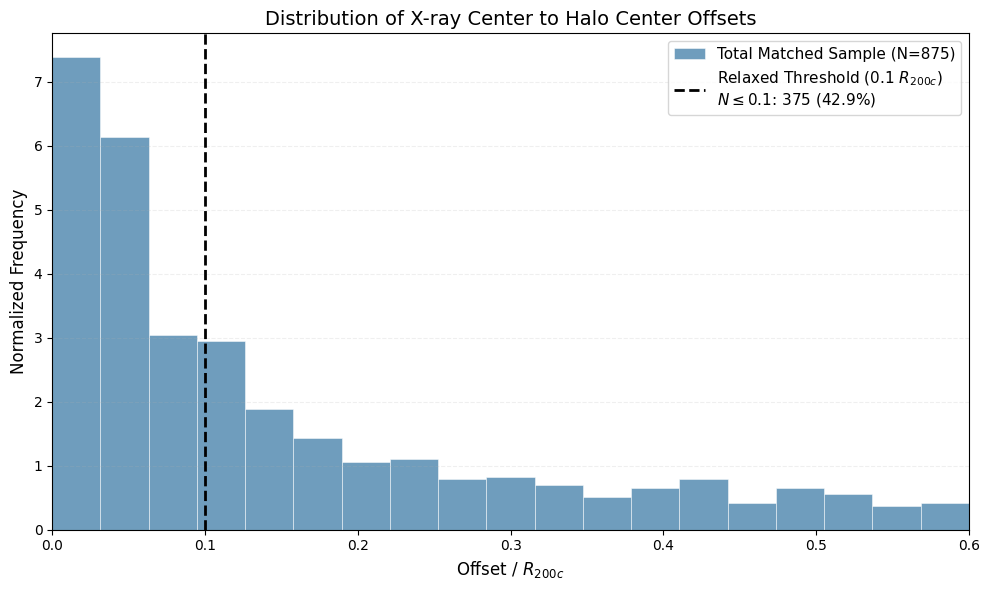

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
file_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
df = pd.read_csv(file_path)

# 2. ENSURE NUMERIC TYPE
df["offset_r200c"] = pd.to_numeric(df["offset_r200c"], errors="coerce")

# Keep only rows with valid offsets
df_clean = df.dropna(subset=["offset_r200c"]).copy()

# 3. CALCULATE STATISTICS FOR THRESHOLD (0.1 R200c)
threshold = 0.1
n_total = len(df_clean)
n_relaxed = len(df_clean[df_clean["offset_r200c"] <= threshold])
pct_relaxed = (n_relaxed / n_total) * 100 if n_total > 0 else 0

# 4. PLOTTING
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["offset_r200c"],
    bins=np.linspace(0, 0.6, 20),
    color="#3274a1",
    alpha=0.7,
    density=True,
    edgecolor="white",
    linewidth=0.5,
    label=f"Total Matched Sample (N={n_total})"
)

plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Relaxed Threshold ({threshold} $R_{{200c}}$)\n$N \\leq 0.1$: {n_relaxed} ({pct_relaxed:.1f}%)"
)

# Labels and styling
plt.title("Distribution of X-ray Center to Halo Center Offsets", fontsize=14)
plt.xlabel("Offset / $R_{200c}$", fontsize=12)
plt.ylabel("Normalized Frequency", fontsize=12)

plt.legend(fontsize=11, loc="upper right", frameon=True)
plt.grid(axis="y", alpha=0.2, linestyle="--")
plt.xlim(0, 0.6)

plt.tight_layout()
plt.show()

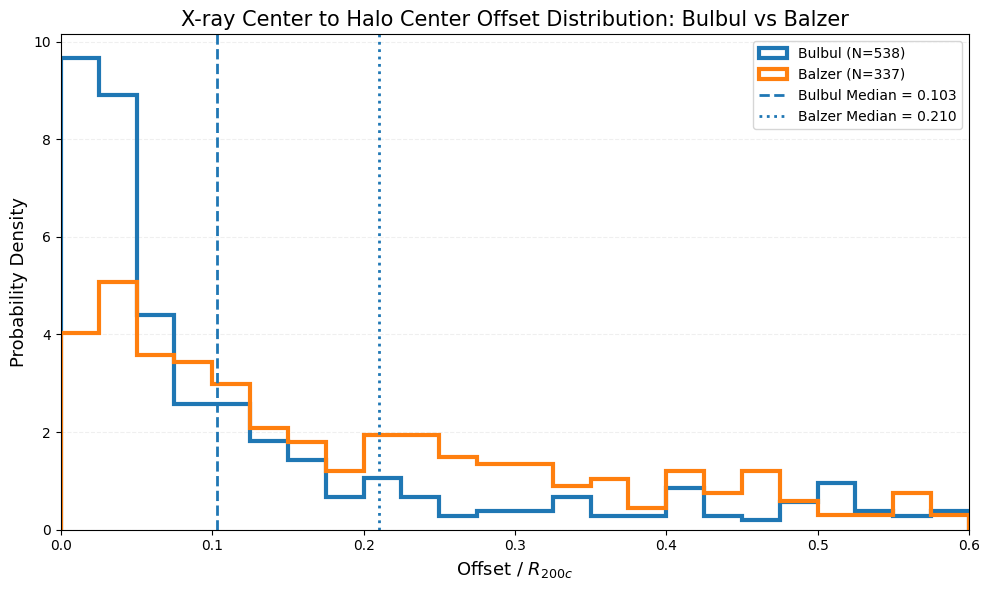

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================
file_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
df = pd.read_csv(file_path)

df["offset_r200c"] = pd.to_numeric(
    df["offset_r200c"],
    errors="coerce"
)

df = df.dropna(subset=["offset_r200c"]).copy()

# ==========================================
# SPLIT CATALOGS
# ==========================================
df_bulbul = df[
    df["xray_source"].str.lower() == "bulbul"
].copy()

df_balzer = df[
    df["xray_source"].str.lower() == "balzer"
].copy()

# ==========================================
# SUMMARY STATISTICS
# ==========================================
median_bulbul = df_bulbul["offset_r200c"].median()
median_balzer = df_balzer["offset_r200c"].median()

# ==========================================
# PLOT
# ==========================================
bins = np.linspace(0, 0.6, 25)

plt.figure(figsize=(10, 6))

# Bulbul
plt.hist(
    df_bulbul["offset_r200c"],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=3,
    label=f"Bulbul (N={len(df_bulbul)})"
)

# Balzer
plt.hist(
    df_balzer["offset_r200c"],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=3,
    label=f"Balzer (N={len(df_balzer)})"
)

# Median lines
plt.axvline(
    median_bulbul,
    linestyle="--",
    linewidth=2,
    label=f"Bulbul Median = {median_bulbul:.3f}"
)

plt.axvline(
    median_balzer,
    linestyle=":",
    linewidth=2,
    label=f"Balzer Median = {median_balzer:.3f}"
)

# ==========================================
# LABELS
# ==========================================
plt.title(
    "X-ray Center to Halo Center Offset Distribution: Bulbul vs Balzer",
    fontsize=15
)

plt.xlabel(
    r"Offset / $R_{200c}$",
    fontsize=13
)

plt.ylabel(
    "Probability Density",
    fontsize=13
)

plt.xlim(0, 0.6)

plt.grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

plt.legend(
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

Median offsets:
Clean: 0.089
Type I (multiple X-ray per halo): 0.092
Type II (multiple halos per X-ray): 0.556


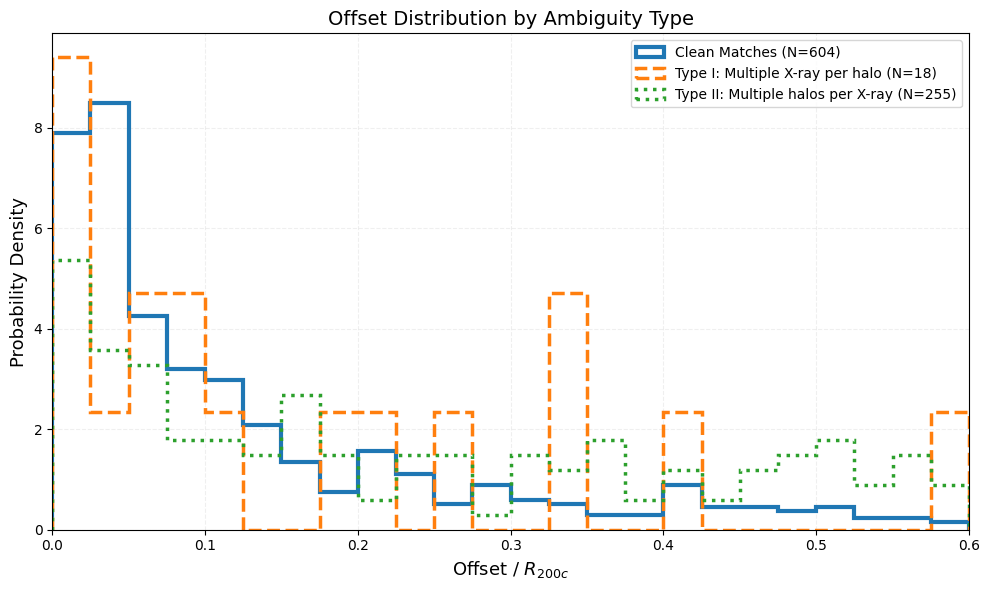

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================
file_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
df = pd.read_csv(file_path)

# ==========================================
# CLEAN OFFSET
# ==========================================
df["offset_r200c"] = pd.to_numeric(df["offset_r200c"], errors="coerce")
df = df.dropna(subset=["offset_r200c"]).copy()

# ==========================================
# ENSURE BOOLEAN FORMAT
# ==========================================
df["multiple_xray_candidates"] = df["multiple_xray_candidates"].astype(bool)
df["multiple_halo_candidates"] = df["multiple_halo_candidates"].astype(bool)

# ==========================================
# SPLITS (CORRECTED DEFINITIONS)
# ==========================================

# Clean systems
clean = df[
    ~df["multiple_xray_candidates"] &
    ~df["multiple_halo_candidates"]
]

# TYPE I: multiple X-ray candidates per halo
type1 = df[df["multiple_xray_candidates"]]

# TYPE II: multiple halos per X-ray source
type2 = df[df["multiple_halo_candidates"]]

# ==========================================
# STATS
# ==========================================
def med(x):
    return np.median(x) if len(x) > 0 else np.nan

print("Median offsets:")
print(f"Clean: {med(clean['offset_r200c']):.3f}")
print(f"Type I (multiple X-ray per halo): {med(type1['offset_r200c']):.3f}")
print(f"Type II (multiple halos per X-ray): {med(type2['offset_r200c']):.3f}")

# ==========================================
# PLOT
# ==========================================
bins = np.linspace(0, 0.6, 25)

plt.figure(figsize=(10, 6))

# Clean
plt.hist(
    clean["offset_r200c"],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=3,
    label=f"Clean Matches (N={len(clean)})"
)

# TYPE I
plt.hist(
    type1["offset_r200c"],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    linestyle="--",
    label=f"Type I: Multiple X-ray per halo (N={len(type1)})"
)

# TYPE II
plt.hist(
    type2["offset_r200c"],
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2.5,
    linestyle=":",
    label=f"Type II: Multiple halos per X-ray (N={len(type2)})"
)

# ==========================================
# FORMATTING
# ==========================================
plt.title("Offset Distribution by Ambiguity Type", fontsize=14)
plt.xlabel(r"Offset / $R_{200c}$", fontsize=13)
plt.ylabel("Probability Density", fontsize=13)

plt.xlim(0, 0.6)
plt.grid(alpha=0.2, linestyle="--")

plt.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

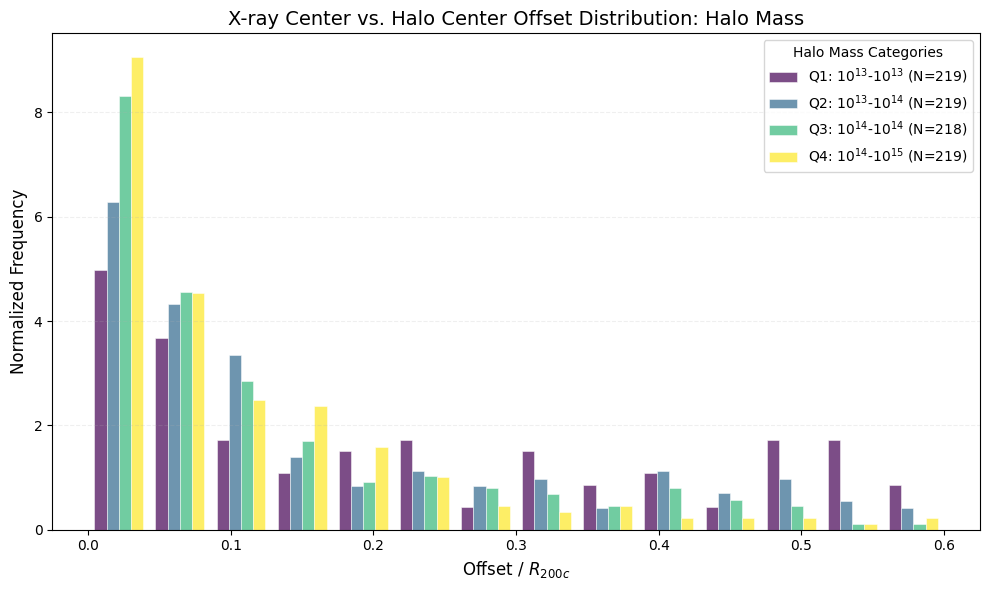

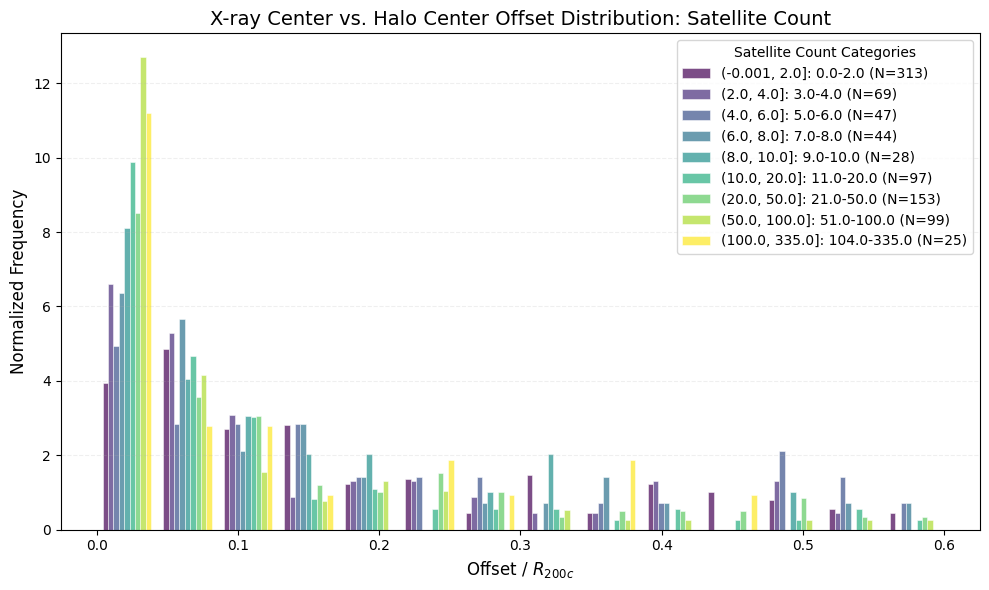

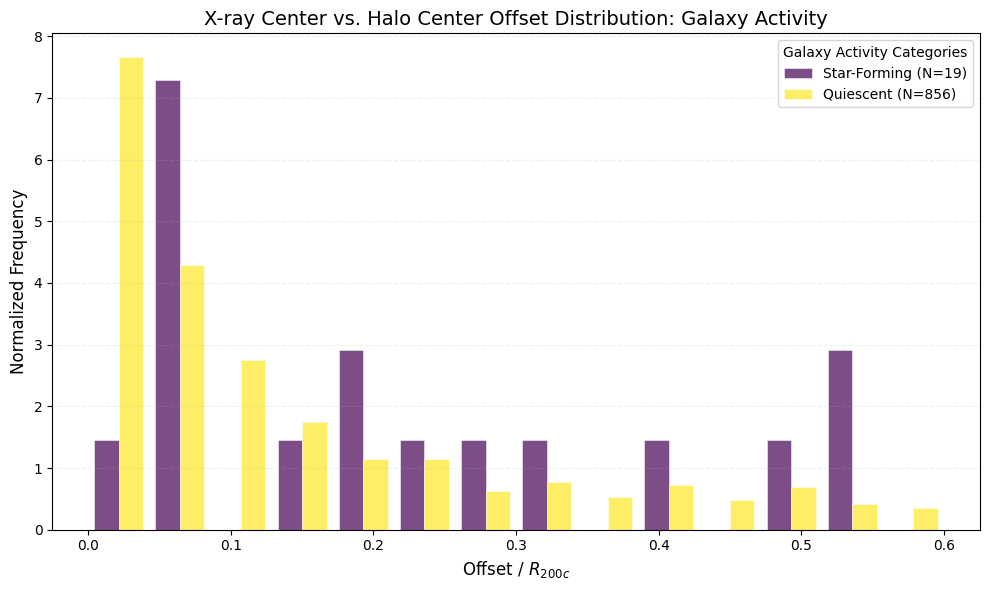

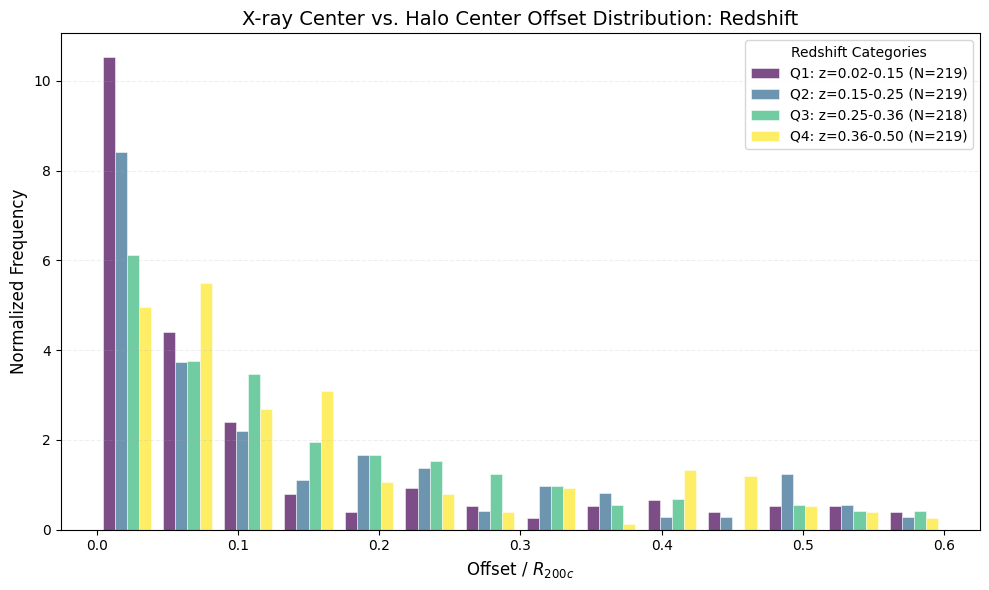

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
file_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
df = pd.read_csv(file_path)

# 2. ENSURE NUMERIC TYPES
cols_to_numeric = ["DESI_M_HALO", "offset_r200c", "DESI_N_SAT", "DESI_Z"]
for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only rows with valid offsets
df_clean = df.dropna(subset=["offset_r200c"]).copy()

# Helper function to format numbers as 10^x
def format_sci(val):
    if val <= 0:
        return "0"
    exponent = int(np.log10(val))
    return f"$10^{{{exponent}}}$"

# Aesthetic plotting function
def plot_binned_histogram_aesthetic(df, split_col, title_label, n_bins=4):
    plt.figure(figsize=(10, 6))
    data_list, labels_list = [], []

    subset = df.dropna(subset=[split_col]).copy()
    if len(subset) == 0:
        plt.close()
        return

    # ---------------- Binning Logic ----------------
    if split_col == "DESI_N_SAT":
        max_val = subset[split_col].max()
        bins = [0, 2, 4, 6, 8, 10, 20, 50, 100]

        if max_val > bins[-1]:
            bins.append(max_val)

        subset["bin_label"] = pd.cut(
            subset[split_col],
            bins=bins,
            include_lowest=True
        )
        groups = subset.groupby("bin_label", observed=False)

    elif subset[split_col].dtype == "bool" or subset[split_col].nunique() <= 2:
        groups = subset.groupby(split_col, observed=False)

    else:
        try:
            subset["bin_label"] = pd.qcut(
                subset[split_col],
                n_bins,
                labels=[f"Q{i+1}" for i in range(n_bins)],
                duplicates="drop"
            )
        except ValueError:
            subset["bin_label"] = pd.cut(subset[split_col], n_bins)

        groups = subset.groupby("bin_label", observed=False)
    # ------------------------------------------------

    n_actual_bins = len(groups)
    colors = plt.cm.viridis(np.linspace(0, 1, n_actual_bins))

    for i, (name, group) in enumerate(groups):
        data_list.append(group["offset_r200c"])
        n_total = len(group)

        if split_col == "DESI_QUIESCENT":
            type_str = "Quiescent" if name else "Star-Forming"
            label_text = f"{type_str} (N={n_total})"

        elif split_col == "DESI_M_HALO":
            min_val, max_val = group[split_col].min(), group[split_col].max()
            label_text = f"{name}: {format_sci(min_val)}-{format_sci(max_val)} (N={n_total})"

        elif split_col == "DESI_Z":
            min_val, max_val = group[split_col].min(), group[split_col].max()
            label_text = f"{name}: z={min_val:.2f}-{max_val:.2f} (N={n_total})"

        else:
            min_val, max_val = group[split_col].min(), group[split_col].max()
            label_text = f"{name}: {min_val:.1f}-{max_val:.1f} (N={n_total})"

        labels_list.append(label_text)

    plt.hist(
        data_list,
        bins=np.linspace(0, 0.6, 15),
        label=labels_list,
        color=colors[:len(data_list)],
        alpha=0.7,
        density=True,
        align="mid",
        histtype="bar",
        edgecolor="white",
        linewidth=0.5
    )

    plt.title(f"X-ray Center vs. Halo Center Offset Distribution: {title_label}", fontsize=14)
    plt.xlabel("Offset / $R_{200c}$", fontsize=12)
    plt.ylabel("Normalized Frequency", fontsize=12)
    plt.legend(title=f"{title_label} Categories", fontsize=10)
    plt.grid(axis="y", alpha=0.2, linestyle="--")
    plt.tight_layout()
    plt.show()

# Generate the plots
plot_binned_histogram_aesthetic(df_clean, "DESI_M_HALO", "Halo Mass")
plot_binned_histogram_aesthetic(df_clean, "DESI_N_SAT", "Satellite Count")
plot_binned_histogram_aesthetic(df_clean, "DESI_QUIESCENT", "Galaxy Activity")
plot_binned_histogram_aesthetic(df_clean, "DESI_Z", "Redshift")

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


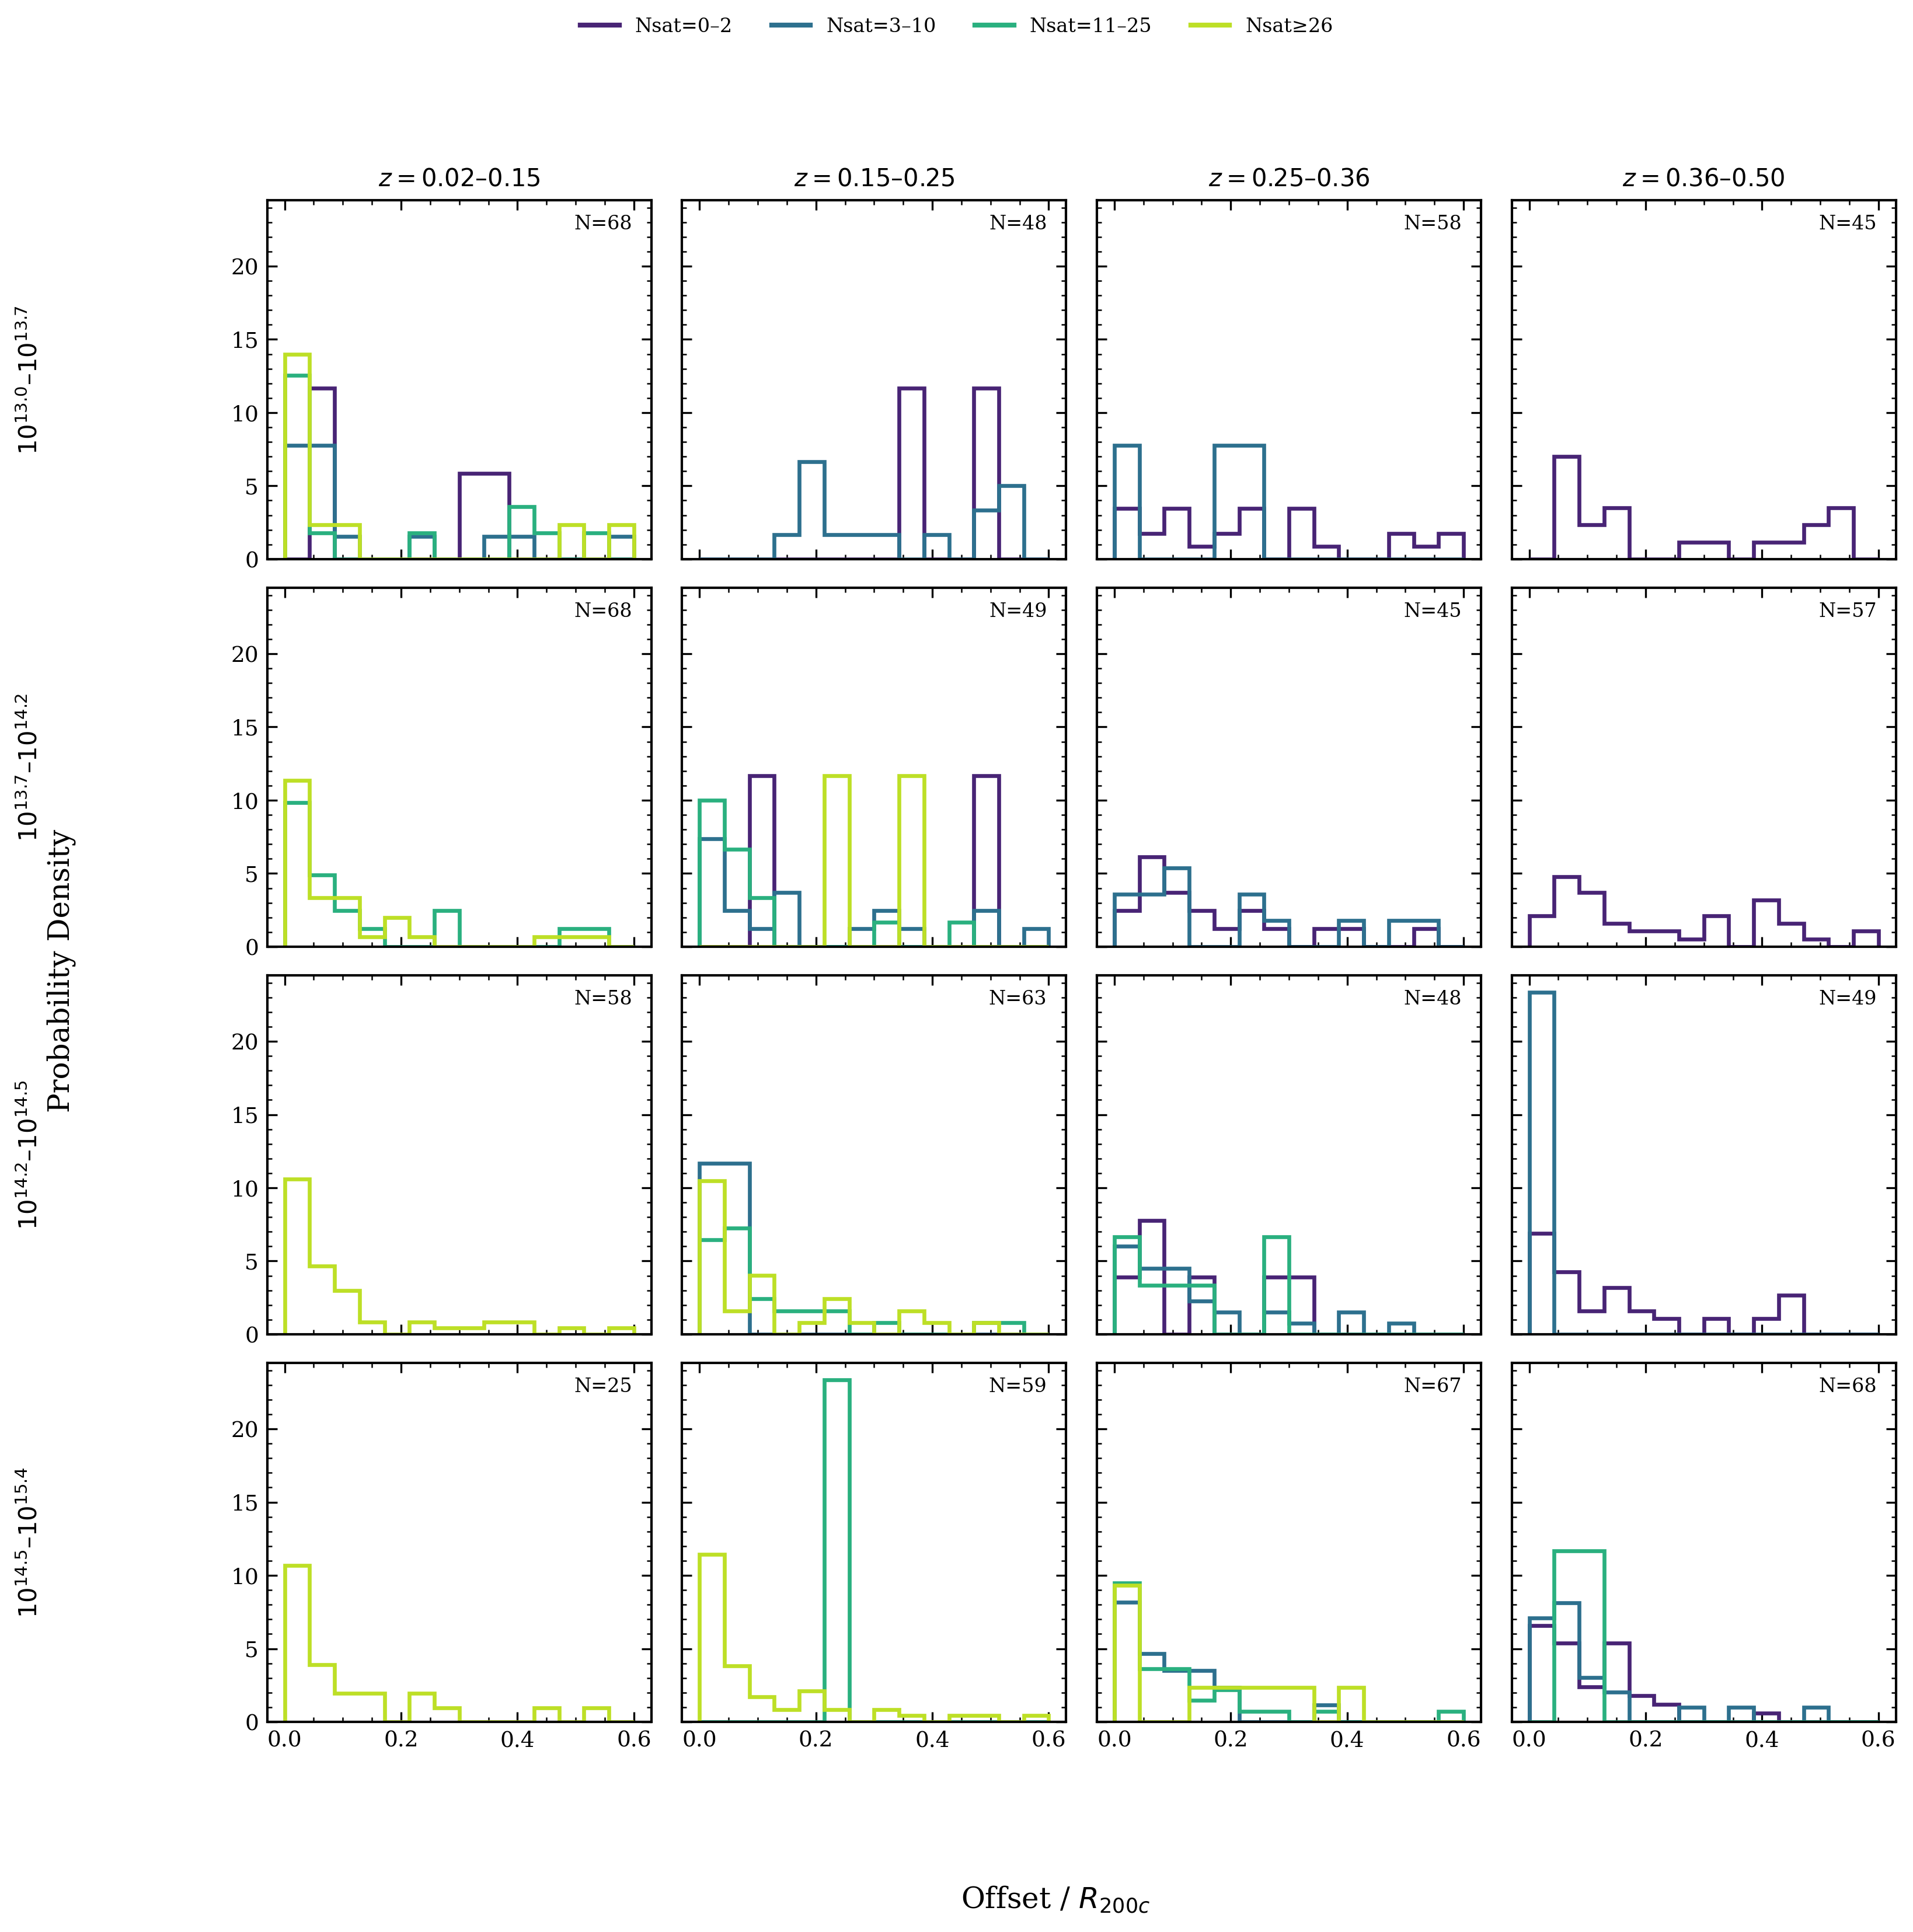

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PUBLICATION STYLE
# ==========================================
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi":300,
        "savefig.dpi":300,
        "savefig.bbox":"tight",
        "font.family":"serif",
        "font.serif":["Times New Roman","DejaVu Serif"],
        "font.size":10,
        "axes.titlesize":10,
        "axes.labelsize":10,
        "xtick.labelsize":9,
        "ytick.labelsize":9,
        "legend.fontsize":8,
        "axes.linewidth":1,
        "xtick.direction":"in",
        "ytick.direction":"in",
        "xtick.top":True,
        "ytick.right":True,
        "xtick.major.size":4,
        "xtick.minor.size":2,
        "ytick.major.size":4,
        "ytick.minor.size":2,
        "legend.frameon":False
    })

set_publication_style()

# ==========================================
# LOAD
# ==========================================
file_path="/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"

df=pd.read_csv(file_path)

# ==========================================
# NUMERIC
# ==========================================
cols=[
    "DESI_M_HALO",
    "DESI_Z",
    "DESI_N_SAT",
    "offset_r200c"
]

for c in cols:
    df[c]=pd.to_numeric(df[c],errors="coerce")

df=df.dropna(subset=cols)

# ==========================================
# HELPERS
# ==========================================
def format_sci(val):

    exponent=np.log10(val)

    return f"$10^{{{exponent:.1f}}}$"

# ==========================================
# MASS BINNING
# ==========================================
mass_qcut=pd.qcut(
    df["DESI_M_HALO"],
    q=4,
    duplicates="drop"
)

df["mass_bin"]=mass_qcut

mass_ranges=[]

for interval in mass_qcut.cat.categories:

    low=interval.left
    high=interval.right

    mass_ranges.append(
        f"{format_sci(low)}–{format_sci(high)}"
    )

# ==========================================
# REDSHIFT BINNING
# ==========================================
z_qcut=pd.qcut(
    df["DESI_Z"],
    q=4,
    duplicates="drop"
)

df["z_bin"]=z_qcut

z_ranges=[]

for interval in z_qcut.cat.categories:

    z_ranges.append(
        f"{interval.left:.2f}–{interval.right:.2f}"
    )

# ==========================================
# SATELLITE BINS
# ==========================================
sat_bins=[0,2,10,25,np.inf]

sat_labels=[
    "Nsat=0–2",
    "Nsat=3–10",
    "Nsat=11–25",
    "Nsat≥26"
]

df["sat_bin"]=pd.cut(
    df["DESI_N_SAT"],
    bins=sat_bins,
    labels=sat_labels,
    include_lowest=True
)

colors=plt.cm.viridis(
    np.linspace(.1,.9,4)
)

# ==========================================
# PLOT
# ==========================================
fig,axes=plt.subplots(
    4,
    4,
    figsize=(12,11),
    sharex=True,
    sharey=True
)

offset_bins=np.linspace(0,.6,15)

for i,mass_interval in enumerate(mass_qcut.cat.categories):

    for j,z_interval in enumerate(z_qcut.cat.categories):

        ax=axes[i,j]

        subset=df[
            (df["mass_bin"]==mass_interval)&
            (df["z_bin"]==z_interval)
        ]

        for k,sat in enumerate(sat_labels):

            s=subset[
                subset["sat_bin"]==sat
            ]

            if len(s)==0:
                continue

            ax.hist(
                s["offset_r200c"],
                bins=offset_bins,
                density=True,
                histtype="step",
                linewidth=1.6,
                color=colors[k]
            )

        ax.text(
            .95,
            .92,
            f"N={len(subset)}",
            transform=ax.transAxes,
            ha="right",
            fontsize=8
        )

        ax.minorticks_on()

# ------------------------
# Column labels (redshift)
# ------------------------

for j in range(4):

    axes[0,j].set_title(
        f"$z={z_ranges[j]}$"
    )

# ------------------------
# Row labels (halo mass)
# ------------------------

for i in range(4):

    axes[i,0].annotate(
        mass_ranges[i],
        xy=(-0.65,.5),
        xycoords='axes fraction',
        rotation=90,
        va='center'
    )

# ------------------------
# Labels
# ------------------------

fig.supxlabel(
    r"Offset / $R_{200c}$"
)

fig.supylabel(
    "Probability Density"
)

# ------------------------
# Legend
# ------------------------

handles=[
    plt.Line2D(
        [0],[0],
        color=colors[i],
        lw=2,
        label=sat_labels[i]
    )
    for i in range(4)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=4
)

plt.subplots_adjust(
    top=.90,
    wspace=.08,
    hspace=.08
)

plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


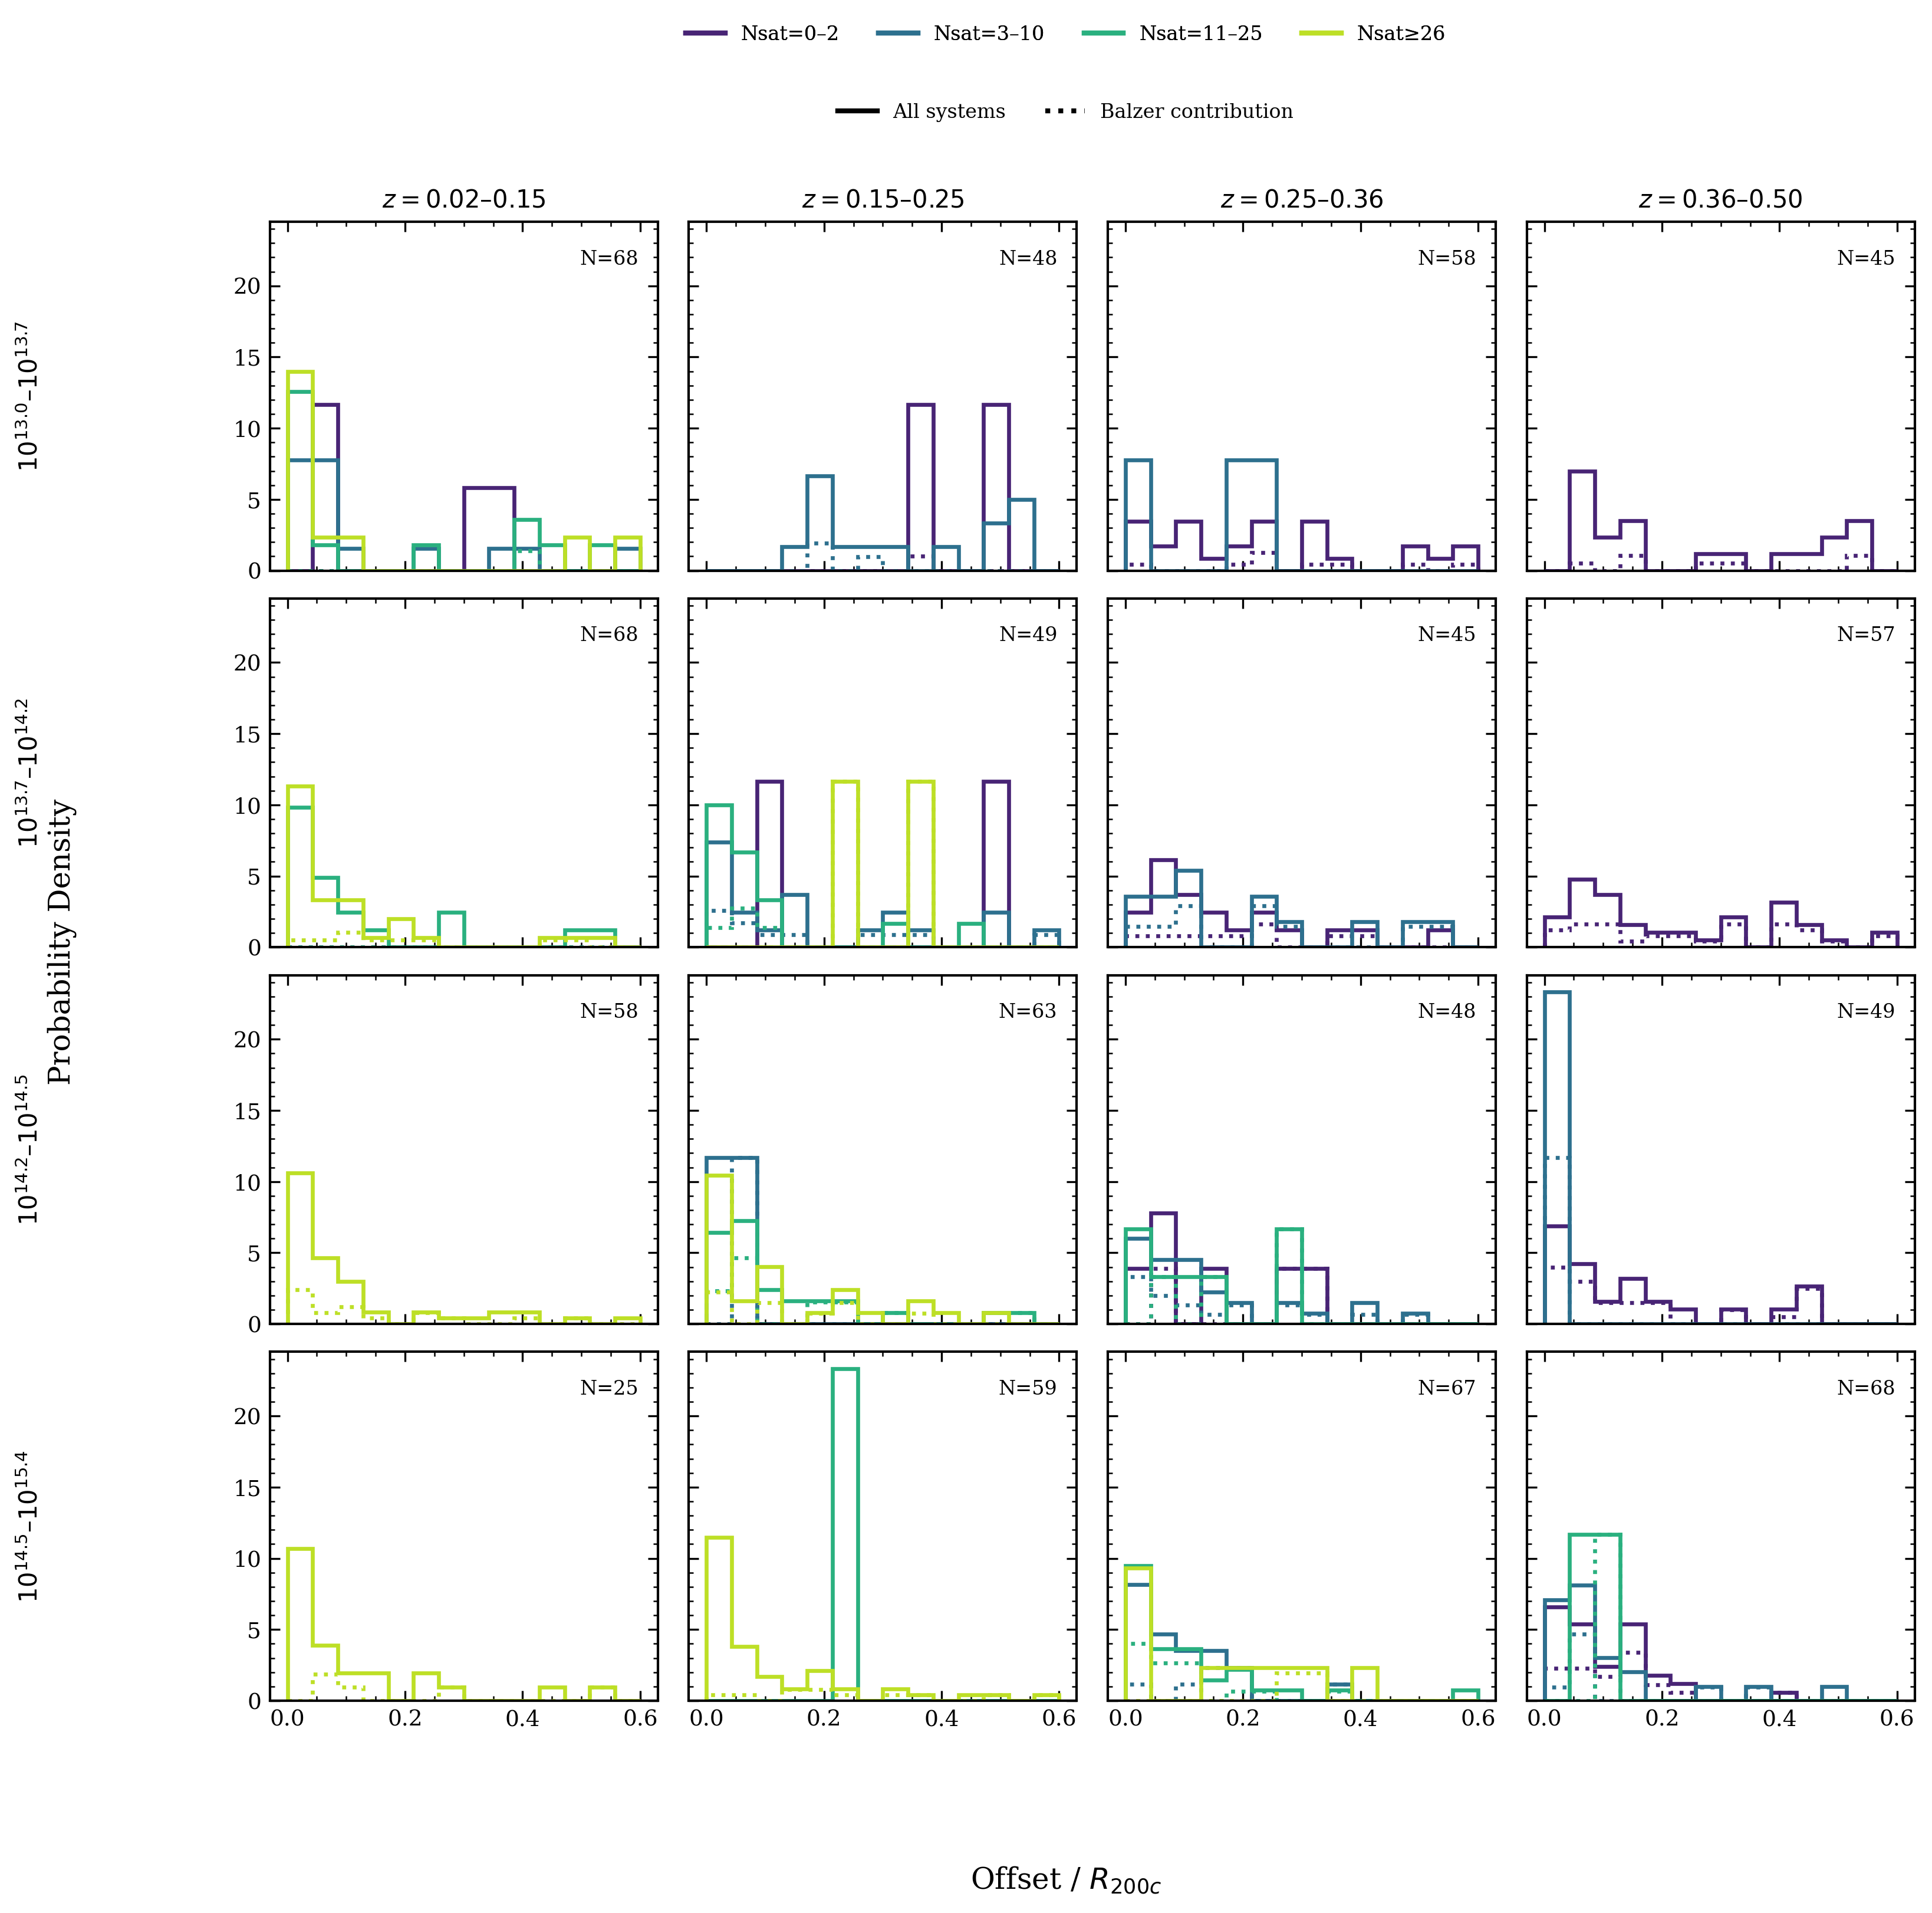

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PUBLICATION STYLE
# ==========================================
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi":300,
        "savefig.dpi":300,
        "savefig.bbox":"tight",
        "font.family":"serif",
        "font.serif":["Times New Roman","DejaVu Serif"],
        "font.size":10,
        "axes.titlesize":10,
        "axes.labelsize":10,
        "xtick.labelsize":9,
        "ytick.labelsize":9,
        "legend.fontsize":8,
        "axes.linewidth":1,
        "xtick.direction":"in",
        "ytick.direction":"in",
        "xtick.top":True,
        "ytick.right":True,
        "xtick.major.size":4,
        "xtick.minor.size":2,
        "ytick.major.size":4,
        "ytick.minor.size":2,
        "legend.frameon":False
    })

set_publication_style()

# ==========================================
# LOAD
# ==========================================
file_path="/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"

df=pd.read_csv(file_path)



# ==========================================
# NUMERIC
# ==========================================
cols=[
    "DESI_M_HALO",
    "DESI_Z",
    "DESI_N_SAT",
    "offset_r200c"
]

for c in cols:
    df[c]=pd.to_numeric(df[c],errors="coerce")

df=df.dropna(subset=cols)

# ==========================================
# HELPERS
# ==========================================
def format_sci(val):

    exponent=np.log10(val)

    return f"$10^{{{exponent:.1f}}}$"


# ==========================================
# MASS BINNING
# ==========================================
mass_qcut=pd.qcut(
    df["DESI_M_HALO"],
    q=4,
    duplicates="drop"
)

df["mass_bin"]=mass_qcut

mass_ranges=[]

for interval in mass_qcut.cat.categories:

    mass_ranges.append(
        f"{format_sci(interval.left)}–{format_sci(interval.right)}"
    )

# ==========================================
# REDSHIFT BINNING
# ==========================================
z_qcut=pd.qcut(
    df["DESI_Z"],
    q=4,
    duplicates="drop"
)

df["z_bin"]=z_qcut

z_ranges=[]

for interval in z_qcut.cat.categories:

    z_ranges.append(
        f"{interval.left:.2f}–{interval.right:.2f}"
    )

# ==========================================
# SATELLITE BINS
# ==========================================
sat_bins=[0,2,10,25,np.inf]

sat_labels=[
    "Nsat=0–2",
    "Nsat=3–10",
    "Nsat=11–25",
    "Nsat≥26"
]

df["sat_bin"]=pd.cut(
    df["DESI_N_SAT"],
    bins=sat_bins,
    labels=sat_labels,
    include_lowest=True
)

colors=plt.cm.viridis(
    np.linspace(.1,.9,4)
)

# ==========================================
# FIGURE
# ==========================================
fig,axes=plt.subplots(
    4,
    4,
    figsize=(12,11),
    sharex=True,
    sharey=True
)

offset_bins=np.linspace(0,.6,15)

# bin width needed for density normalization
bin_width=np.diff(offset_bins)[0]

# ==========================================
# PANELS
# ==========================================
for i,mass_interval in enumerate(mass_qcut.cat.categories):

    for j,z_interval in enumerate(z_qcut.cat.categories):

        ax=axes[i,j]

        subset=df[
            (df["mass_bin"]==mass_interval)&
            (df["z_bin"]==z_interval)
        ]

        for k,sat in enumerate(sat_labels):

            s=subset[
                subset["sat_bin"]==sat
            ]

            if len(s)==0:
                continue

            # -----------------------
            # Original curve
            # -----------------------
            ax.hist(
                s["offset_r200c"],
                bins=offset_bins,
                density=True,
                histtype="step",
                linewidth=1.6,
                color=colors[k]
            )

            # -----------------------
            # Balzer overlay
            # -----------------------
            balzer=s[
                s["xray_source"]
                .astype(str)
                .str.lower()
                .str.strip()
                == "balzer"
            ]

            if len(balzer)>0:

                weights=np.ones(
                    len(balzer)
                )/(len(s)*bin_width)

                ax.hist(
                    balzer["offset_r200c"],
                    bins=offset_bins,
                    weights=weights,
                    density=False,
                    histtype="step",
                    linewidth=1.6,
                    linestyle=":",
                    color=colors[k]
                )

        ax.text(
            .95,
            .92,
            f"N={len(subset)}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8
        )

        ax.minorticks_on()

# ==========================================
# LABELS
# ==========================================
for j in range(4):
    axes[0,j].set_title(
        f"$z={z_ranges[j]}$"
    )

for i in range(4):
    axes[i,0].annotate(
        mass_ranges[i],
        xy=(-0.65,.5),
        xycoords='axes fraction',
        rotation=90,
        va='center'
    )

fig.supxlabel(
    r"Offset / $R_{200c}$"
)

fig.supylabel(
    "Probability Density"
)

# ==========================================
# LEGENDS
# ==========================================
handles=[
    plt.Line2D(
        [0],[0],
        color=colors[i],
        lw=2,
        label=sat_labels[i]
    )
    for i in range(4)
]

legend1=fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5,.98),
    ncol=4
)

style_handles=[
    plt.Line2D(
        [0],[0],
        color="black",
        lw=2,
        linestyle="-",
        label="All systems"
    ),
    plt.Line2D(
        [0],[0],
        color="black",
        lw=2,
        linestyle=":",
        label="Balzer contribution"
    )
]

legend2=fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.5,.94),
    ncol=2
)

fig.add_artist(legend1)

plt.subplots_adjust(
    top=.87,
    wspace=.08,
    hspace=.08
)

plt.show()

Remaining clean systems: 604


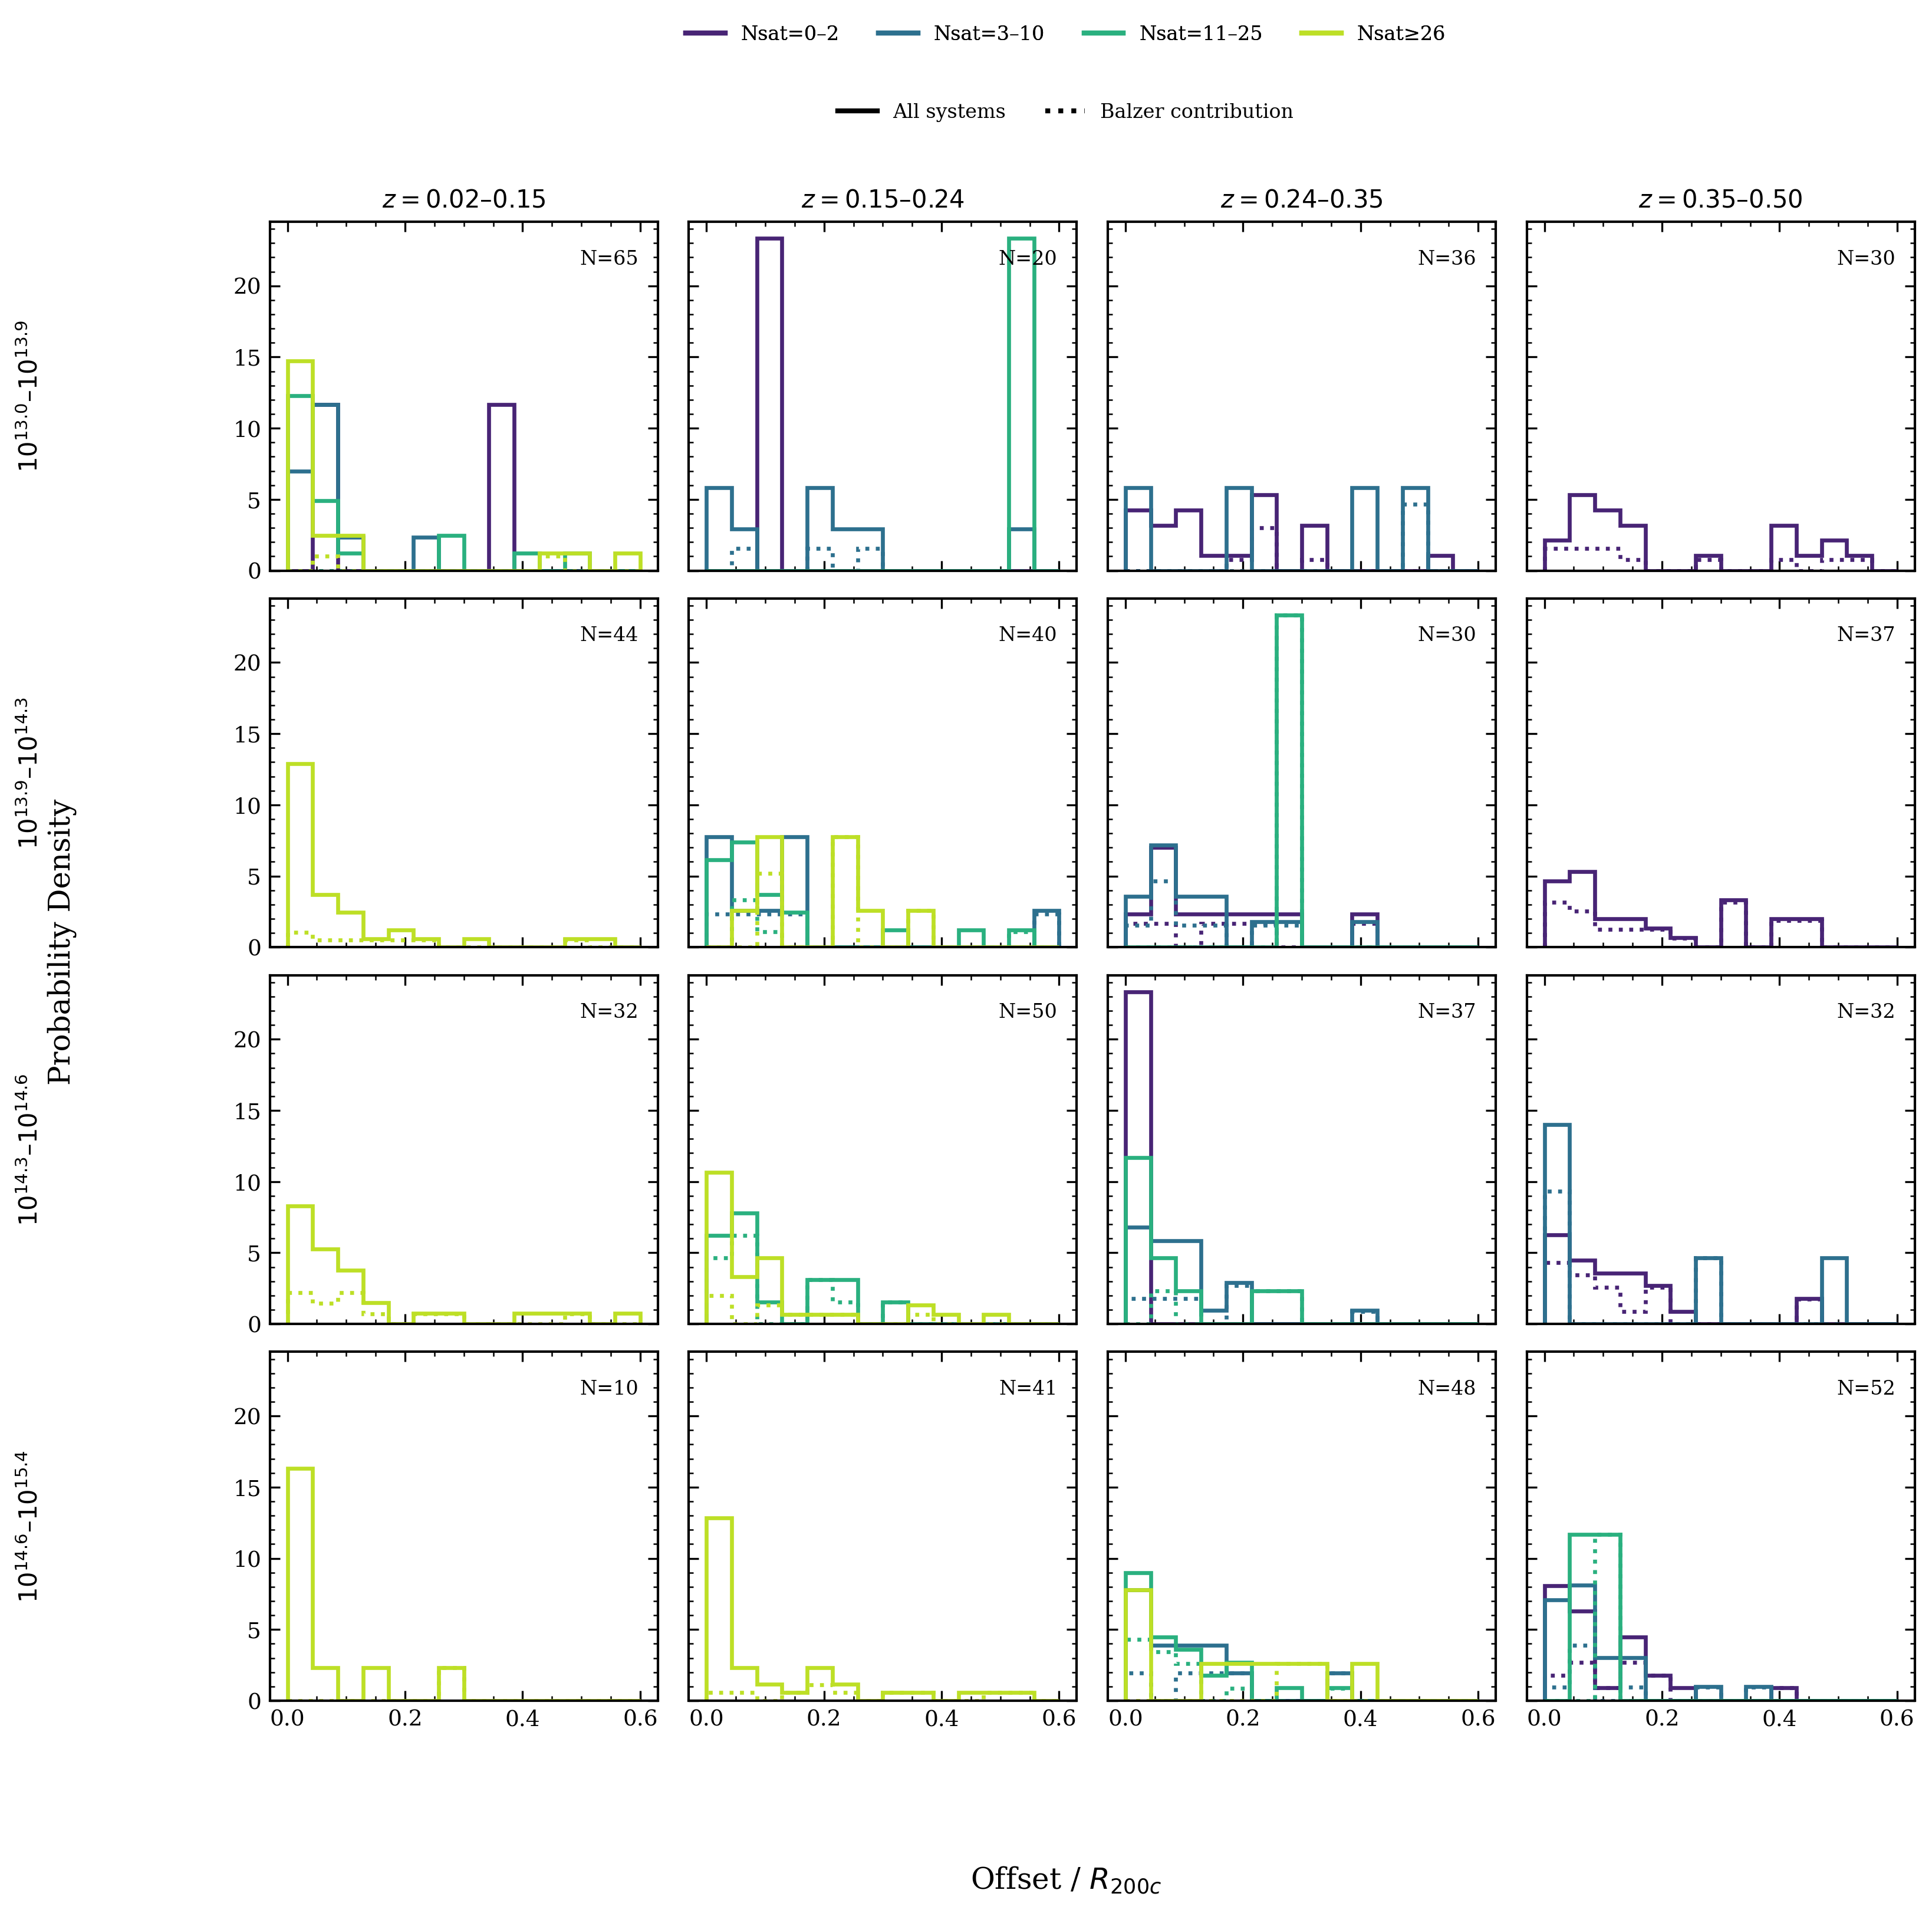

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PUBLICATION STYLE
# ==========================================
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi":300,
        "savefig.dpi":300,
        "savefig.bbox":"tight",
        "font.family":"serif",
        "font.serif":["Times New Roman","DejaVu Serif"],
        "font.size":10,
        "axes.titlesize":10,
        "axes.labelsize":10,
        "xtick.labelsize":9,
        "ytick.labelsize":9,
        "legend.fontsize":8,
        "axes.linewidth":1,
        "xtick.direction":"in",
        "ytick.direction":"in",
        "xtick.top":True,
        "ytick.right":True,
        "xtick.major.size":4,
        "xtick.minor.size":2,
        "ytick.major.size":4,
        "ytick.minor.size":2,
        "legend.frameon":False
    })

set_publication_style()

# ==========================================
# LOAD
# ==========================================
file_path="/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"

df=pd.read_csv(file_path)

# ==========================================
# NUMERIC
# ==========================================
cols=[
    "DESI_M_HALO",
    "DESI_Z",
    "DESI_N_SAT",
    "offset_r200c"
]

for c in cols:
    df[c]=pd.to_numeric(
        df[c],
        errors="coerce"
    )

# ==========================================
# REMOVE AMBIGUOUS SYSTEMS
# ==========================================

df["multiple_xray_candidates"]=(
    df["multiple_xray_candidates"]
    .astype(bool)
)

df["multiple_halo_candidates"]=(
    df["multiple_halo_candidates"]
    .astype(bool)
)

df=df[
    (~df["multiple_xray_candidates"]) &
    (~df["multiple_halo_candidates"])
]

# ==========================================
# FINAL CLEANING
# ==========================================
df=df.dropna(subset=cols).copy()

print(
    f"Remaining clean systems: {len(df):,}"
)

# ==========================================
# HELPERS
# ==========================================
def format_sci(val):

    exponent=np.log10(val)

    return f"$10^{{{exponent:.1f}}}$"

# ==========================================
# MASS BINNING
# ==========================================
mass_qcut=pd.qcut(
    df["DESI_M_HALO"],
    q=4,
    duplicates="drop"
)

df["mass_bin"]=mass_qcut

mass_ranges=[]

for interval in mass_qcut.cat.categories:

    mass_ranges.append(
        f"{format_sci(interval.left)}–"
        f"{format_sci(interval.right)}"
    )

# ==========================================
# REDSHIFT BINNING
# ==========================================
z_qcut=pd.qcut(
    df["DESI_Z"],
    q=4,
    duplicates="drop"
)

df["z_bin"]=z_qcut

z_ranges=[]

for interval in z_qcut.cat.categories:

    z_ranges.append(
        f"{interval.left:.2f}–"
        f"{interval.right:.2f}"
    )

# ==========================================
# SATELLITE BINS
# ==========================================
sat_bins=[0,2,10,25,np.inf]

sat_labels=[
    "Nsat=0–2",
    "Nsat=3–10",
    "Nsat=11–25",
    "Nsat≥26"
]

df["sat_bin"]=pd.cut(
    df["DESI_N_SAT"],
    bins=sat_bins,
    labels=sat_labels,
    include_lowest=True
)

colors=plt.cm.viridis(
    np.linspace(.1,.9,4)
)

# ==========================================
# FIGURE
# ==========================================
fig,axes=plt.subplots(
    4,
    4,
    figsize=(12,11),
    sharex=True,
    sharey=True
)

offset_bins=np.linspace(0,.6,15)

bin_width=np.diff(
    offset_bins
)[0]

# ==========================================
# PANELS
# ==========================================
for i,mass_interval in enumerate(
    mass_qcut.cat.categories
):

    for j,z_interval in enumerate(
        z_qcut.cat.categories
    ):

        ax=axes[i,j]

        subset=df[
            (df["mass_bin"]==mass_interval)&
            (df["z_bin"]==z_interval)
        ]

        for k,sat in enumerate(
            sat_labels
        ):

            s=subset[
                subset["sat_bin"]==sat
            ]

            if len(s)==0:
                continue

            # -----------------------
            # Original curve
            # -----------------------
            ax.hist(
                s["offset_r200c"],
                bins=offset_bins,
                density=True,
                histtype="step",
                linewidth=1.6,
                color=colors[k]
            )

            # -----------------------
            # Balzer overlay
            # -----------------------
            balzer=s[
                s["xray_source"]
                .astype(str)
                .str.lower()
                .str.strip()
                == "balzer"
            ]

            if len(balzer)>0:

                weights=np.ones(
                    len(balzer)
                )/(len(s)*bin_width)

                ax.hist(
                    balzer["offset_r200c"],
                    bins=offset_bins,
                    weights=weights,
                    density=False,
                    histtype="step",
                    linewidth=1.6,
                    linestyle=":",
                    color=colors[k]
                )

        ax.text(
            .95,
            .92,
            f"N={len(subset)}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8
        )

        ax.minorticks_on()

# ==========================================
# COLUMN LABELS
# ==========================================
for j in range(4):

    axes[0,j].set_title(
        f"$z={z_ranges[j]}$"
    )

# ==========================================
# ROW LABELS
# ==========================================
for i in range(4):

    axes[i,0].annotate(
        mass_ranges[i],
        xy=(-0.65,.5),
        xycoords='axes fraction',
        rotation=90,
        va='center'
    )

# ==========================================
# GLOBAL LABELS
# ==========================================
fig.supxlabel(
    r"Offset / $R_{200c}$"
)

fig.supylabel(
    "Probability Density"
)

# ==========================================
# SATELLITE LEGEND
# ==========================================
handles=[

    plt.Line2D(
        [0],[0],
        color=colors[i],
        lw=2,
        label=sat_labels[i]
    )

    for i in range(4)
]

legend1=fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5,.98),
    ncol=4
)

# ==========================================
# LINE STYLE LEGEND
# ==========================================
style_handles=[

    plt.Line2D(
        [0],[0],
        color="black",
        lw=2,
        linestyle="-",
        label="All systems"
    ),

    plt.Line2D(
        [0],[0],
        color="black",
        lw=2,
        linestyle=":",
        label="Balzer contribution"
    )
]

legend2=fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.5,.94),
    ncol=2
)

fig.add_artist(
    legend1
)

plt.subplots_adjust(
    top=.87,
    wspace=.08,
    hspace=.08
)

plt.show()

N systems = 875

Gamma parameters:
shape k = 0.665
scale θ = 0.505
mean = 0.336
sigma = 0.412


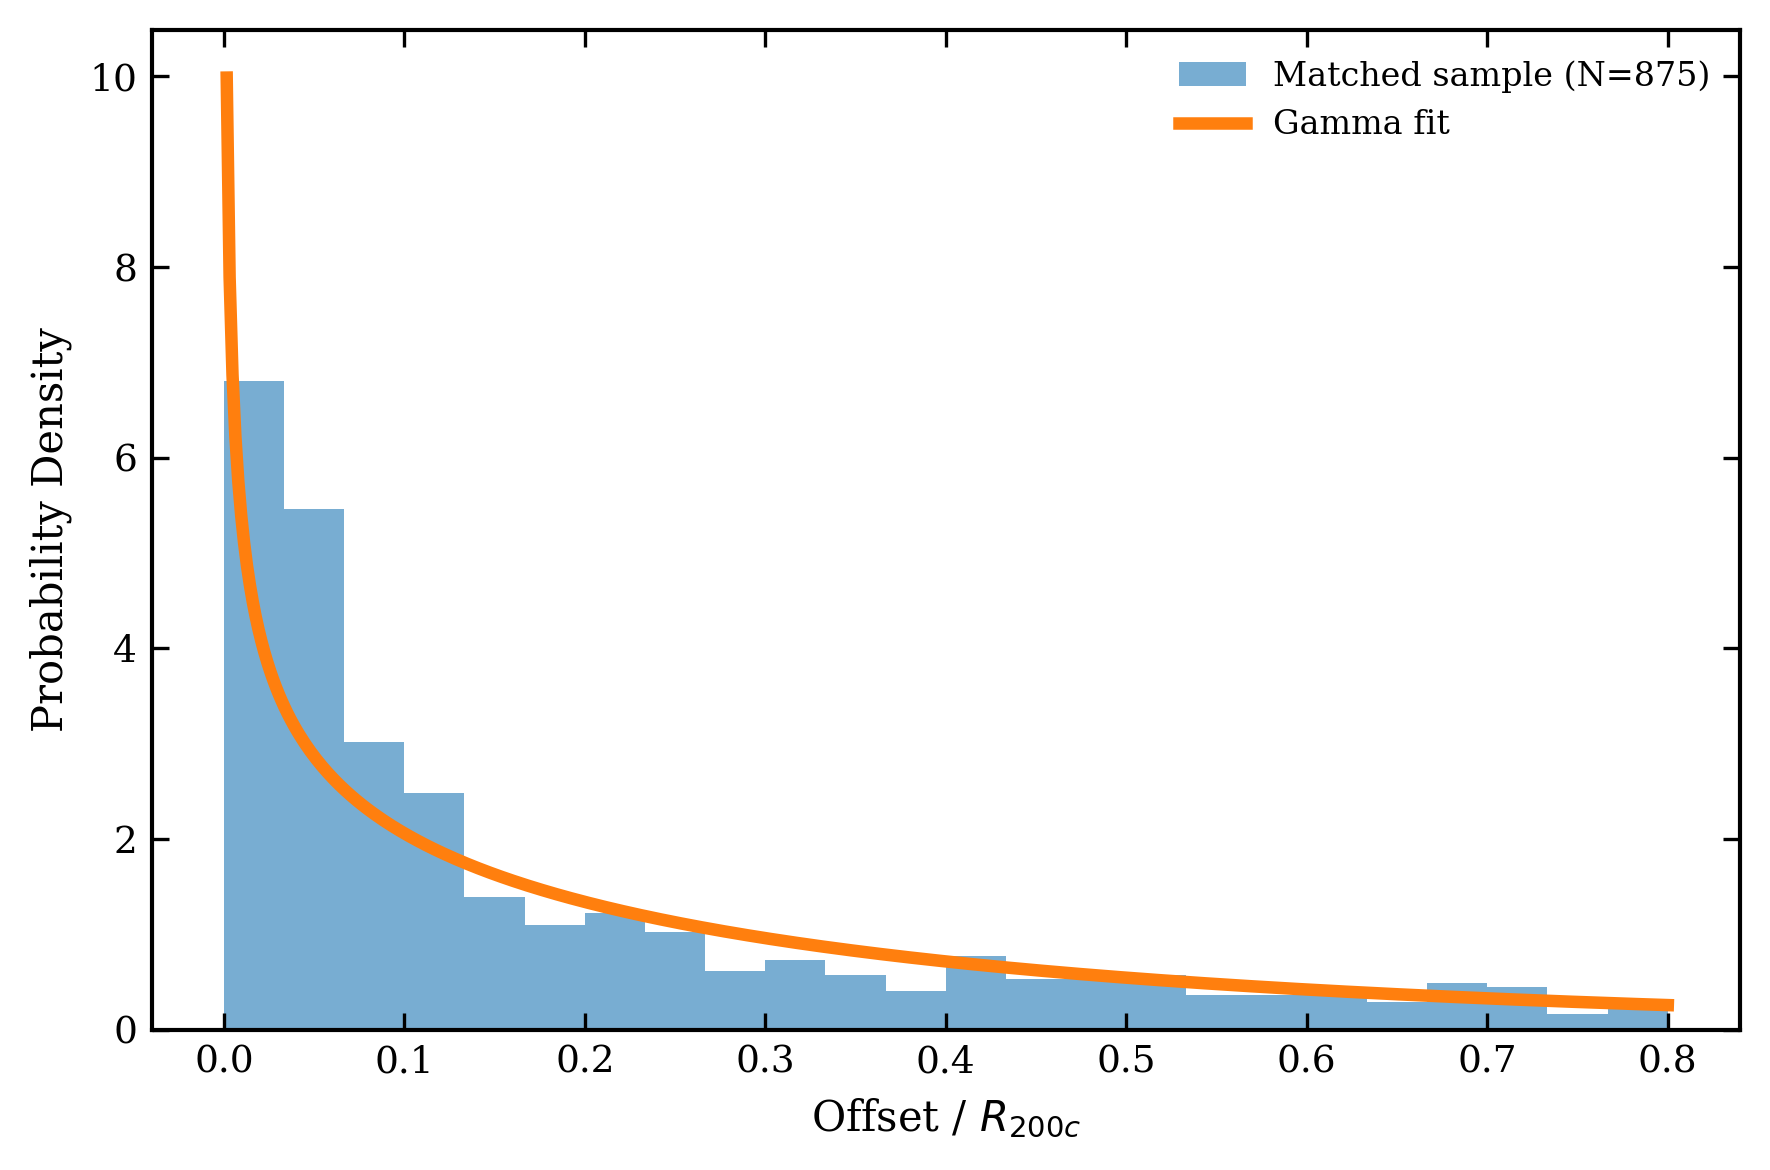

Median=0.134
68 percentile=0.353
90 percentile=1.056


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gamma

# ==========================================
# LOAD
# ==========================================
file_path="/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"

df=pd.read_csv(file_path)

# ==========================================
# CLEAN
# ==========================================
df["offset_r200c"]=pd.to_numeric(
    df["offset_r200c"],
    errors="coerce"
)

df=df.dropna(
    subset=["offset_r200c"]
).copy()

offset=df["offset_r200c"].values

print(
    f"N systems = {len(offset):,}"
)

# ==========================================
# FIT GAMMA
# ==========================================

shape,loc,scale=gamma.fit(
    offset,
    floc=0
)

print("\nGamma parameters:")
print(f"shape k = {shape:.3f}")
print(f"scale θ = {scale:.3f}")

mean=shape*scale
sigma=np.sqrt(shape)*scale

print(f"mean = {mean:.3f}")
print(f"sigma = {sigma:.3f}")

# ==========================================
# PLOT
# ==========================================

x=np.linspace(
    0,
    0.8,
    500
)

pdf=gamma.pdf(
    x,
    a=shape,
    loc=0,
    scale=scale
)

plt.figure(figsize=(6,4))

plt.hist(
    offset,
    bins=np.linspace(0,.8,25),
    density=True,
    alpha=.6,
    label=f"Matched sample (N={len(offset)})"
)

plt.plot(
    x,
    pdf,
    linewidth=3,
    label="Gamma fit"
)

plt.xlabel(
    r"Offset / $R_{200c}$"
)

plt.ylabel(
    "Probability Density"
)

plt.legend()

plt.tight_layout()

plt.show()

print(
    f"Median={np.median(offset):.3f}"
)

print(
    f"68 percentile={np.percentile(offset,68):.3f}"
)

print(
    f"90 percentile={np.percentile(offset,90):.3f}"
)

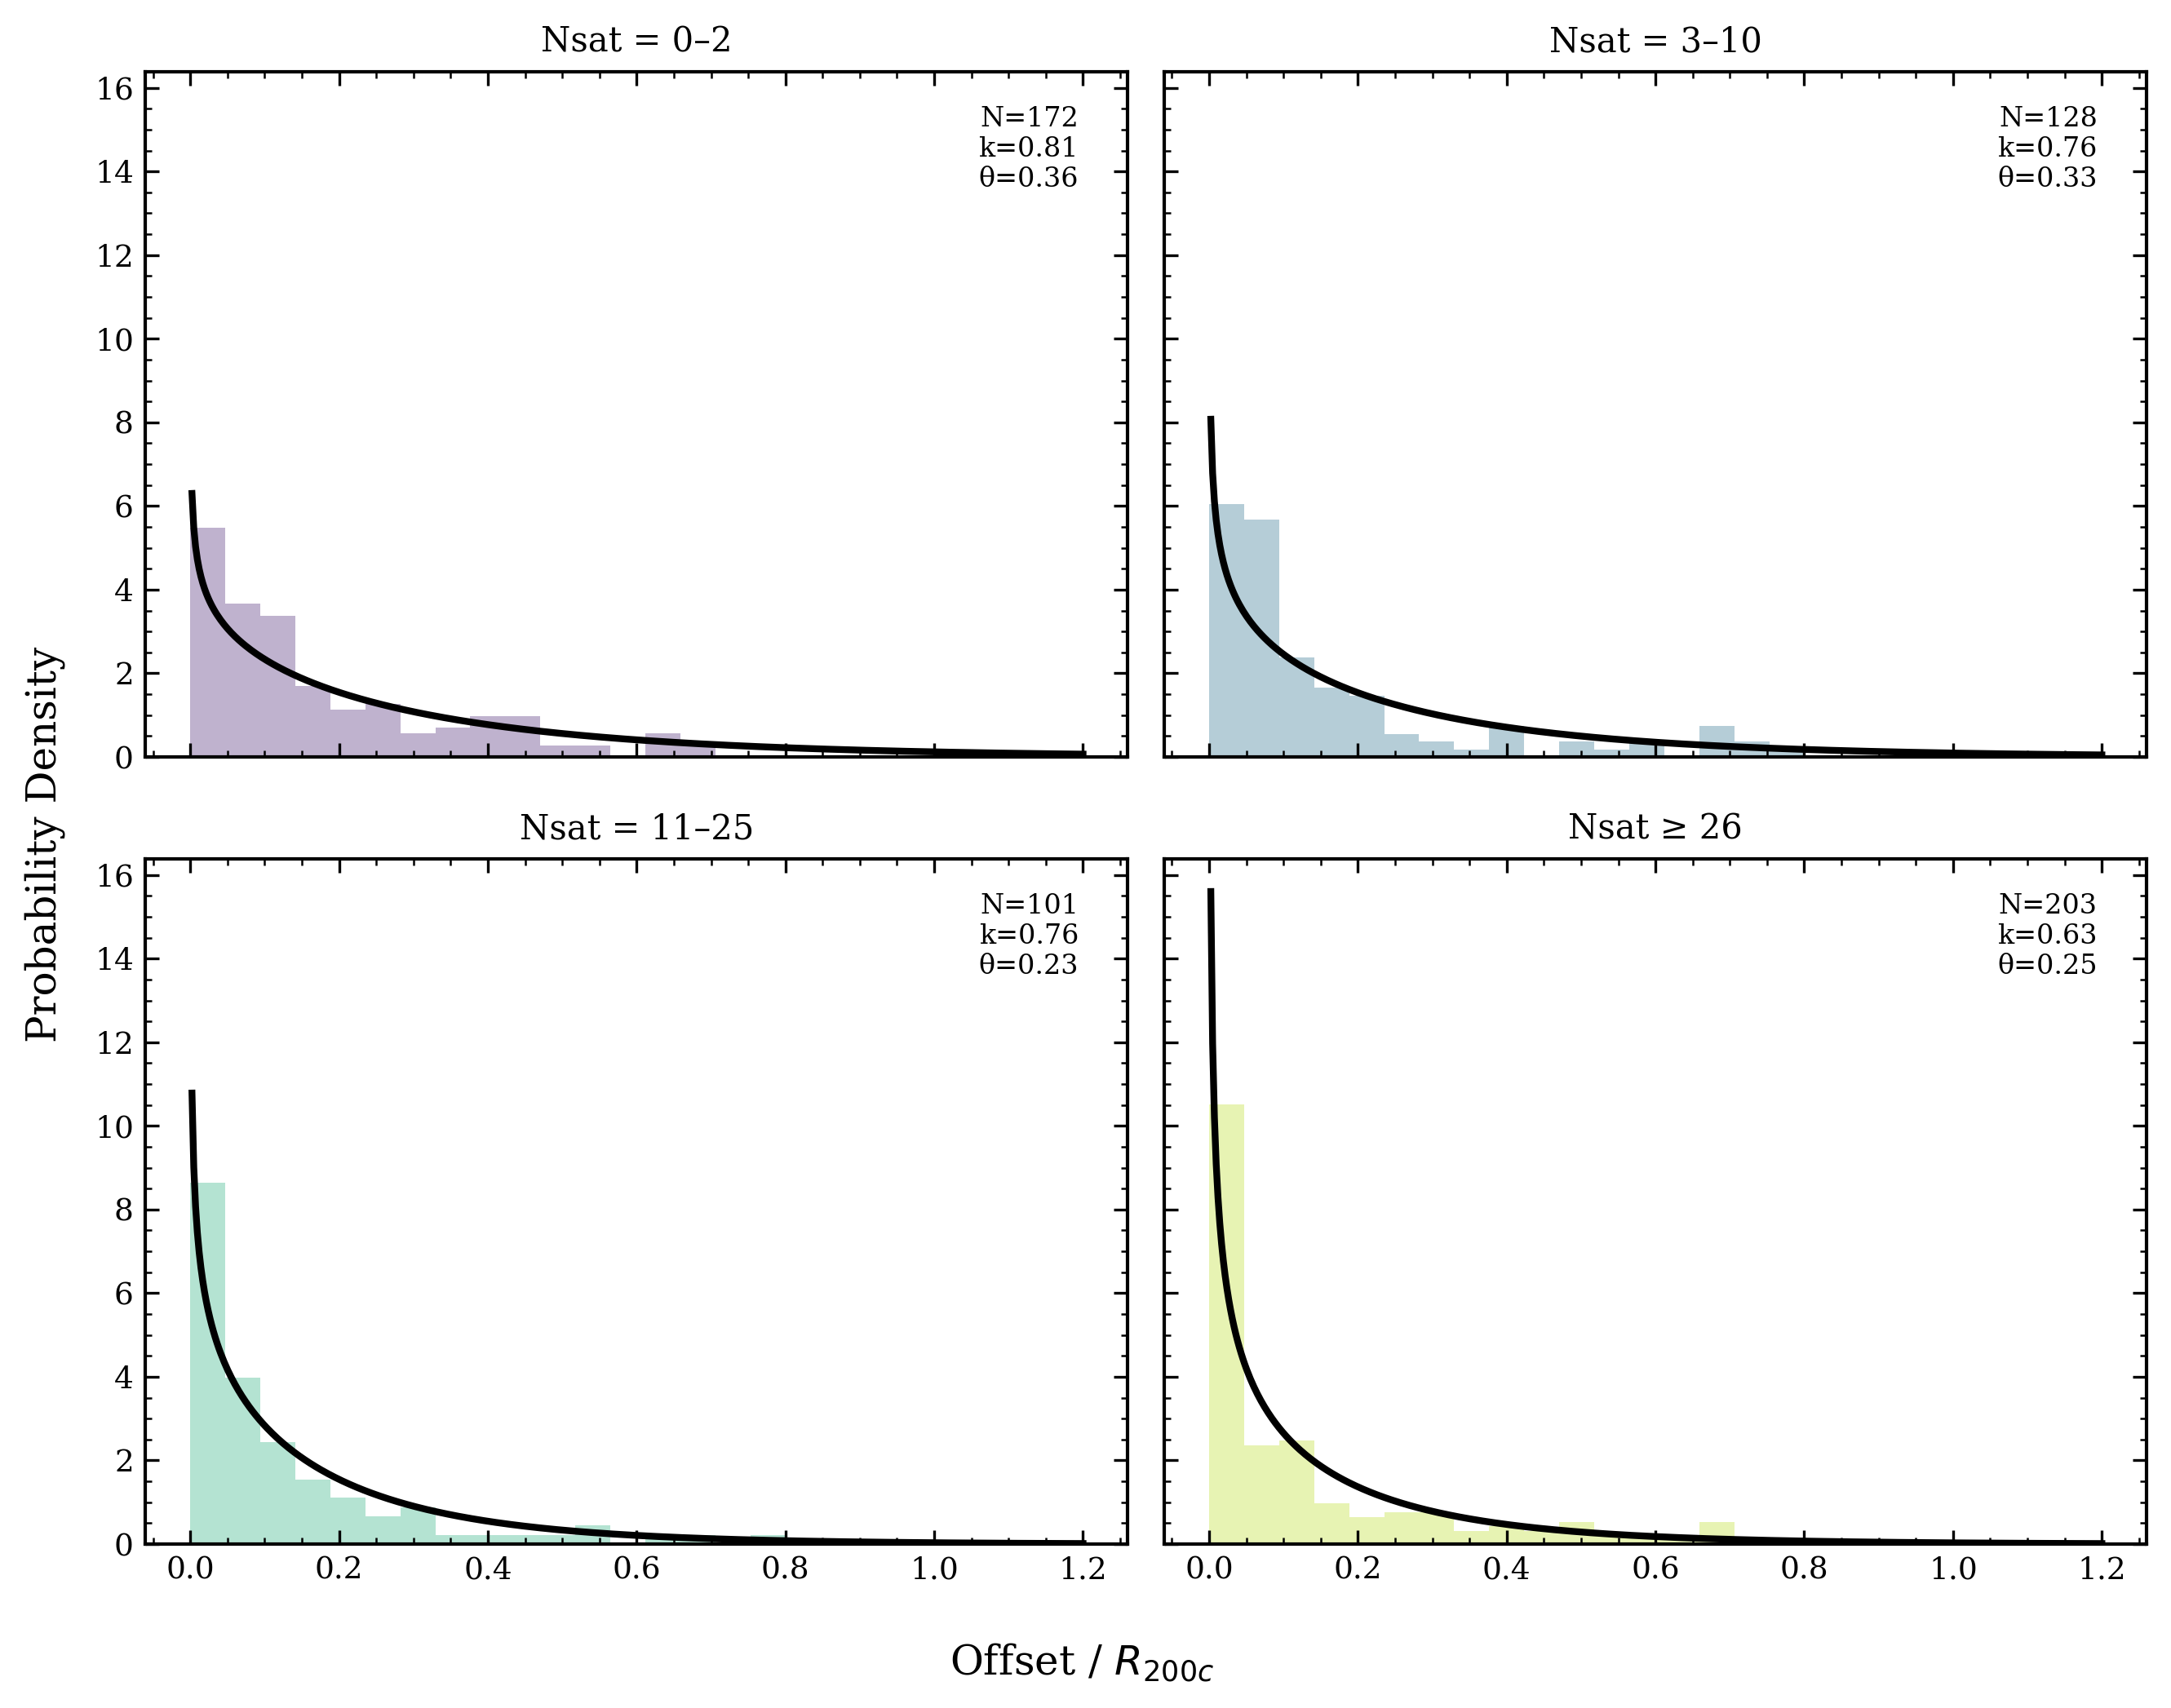

Nsat ≥ 26   N= 203  k=0.631  θ=0.246  mean=0.155


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gamma

# ==========================================
# PUBLICATION STYLE
# ==========================================
def set_publication_style():

    plt.rcParams.update({
        "figure.dpi":300,
        "savefig.dpi":300,
        "savefig.bbox":"tight",
        "font.family":"serif",
        "font.serif":["Times New Roman","DejaVu Serif"],
        "font.size":10,
        "axes.titlesize":10,
        "axes.labelsize":10,
        "xtick.labelsize":9,
        "ytick.labelsize":9,
        "legend.fontsize":8,
        "axes.linewidth":1,
        "xtick.direction":"in",
        "ytick.direction":"in",
        "xtick.top":True,
        "ytick.right":True,
        "xtick.major.size":4,
        "xtick.minor.size":2,
        "ytick.major.size":4,
        "ytick.minor.size":2,
        "legend.frameon":False
    })

set_publication_style()

# ==========================================
# LOAD
# ==========================================
file_path="/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"

df=pd.read_csv(file_path)

# ==========================================
# NUMERIC
# ==========================================
cols=[
    "DESI_N_SAT",
    "offset_r200c"
]

for c in cols:
    df[c]=pd.to_numeric(
        df[c],
        errors="coerce"
    )

df=df.dropna(subset=cols)

# ==========================================
# OPTIONAL:
# remove ambiguous systems
# ==========================================
df=df[
    (~df["multiple_xray_candidates"])&
    (~df["multiple_halo_candidates"])
].copy()

# ==========================================
# SATELLITE BINS
# ==========================================
sat_bins=[0,2,10,25,np.inf]

sat_labels=[
    "Nsat = 0–2",
    "Nsat = 3–10",
    "Nsat = 11–25",
    "Nsat ≥ 26"
]

df["sat_bin"]=pd.cut(
    df["DESI_N_SAT"],
    bins=sat_bins,
    labels=sat_labels,
    include_lowest=True
)

colors=plt.cm.viridis(
    np.linspace(.1,.9,4)
)

# ==========================================
# PLOT
# ==========================================
fig,axes=plt.subplots(
    2,
    2,
    figsize=(9,7),
    sharex=True,
    sharey=True
)

axes=axes.flatten()

x=np.linspace(
    0,
    1.2,
    500
)

for i,label in enumerate(sat_labels):

    ax=axes[i]

    subset=df[
        df["sat_bin"]==label
    ]

    offset=subset[
        "offset_r200c"
    ].values

    N=len(offset)

    if N<10:
        continue

    # ------------------------
    # Gamma fit
    # ------------------------

    shape,loc,scale=gamma.fit(
        offset,
        floc=0
    )

    pdf=gamma.pdf(
        x,
        a=shape,
        scale=scale
    )

    # ------------------------
    # Histogram
    # ------------------------

    ax.hist(
        offset,
        bins=np.linspace(
            0,
            .8,
            18
        ),
        density=True,
        alpha=.35,
        color=colors[i]
    )

    # ------------------------
    # Gamma model
    # ------------------------

    ax.plot(
        x,
        pdf,
        color="black",
        linewidth=2
    )

    # ------------------------
    # Labels
    # ------------------------

    ax.text(
        .95,
        .95,
        f"N={N}\n"
        f"k={shape:.2f}\n"
        f"θ={scale:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8
    )

    ax.set_title(label)

    ax.minorticks_on()

# ==========================================
# LABELS
# ==========================================
fig.supxlabel(
    r"Offset / $R_{200c}$"
)

fig.supylabel(
    "Probability Density"
)

plt.tight_layout()

plt.show()

print(
    f"{label:12s}"
    f"N={N:4d}  "
    f"k={shape:.3f}  "
    f"θ={scale:.3f}  "
    f"mean={shape*scale:.3f}"
)